In [1]:
! pip install --index-url https://mirror2.chabokan.net/pypi/simple/ transformers
! pip install --index-url https://mirror2.chabokan.net/pypi/simple/ torchmetrics
! pip install --index-url https://mirror2.chabokan.net/pypi/simple/ pycocotools
! pip install --index-url https://mirror2.chabokan.net/pypi/simple/ faster-coco-eval

Looking in indexes: https://mirror2.chabokan.net/pypi/simple/
Looking in indexes: https://mirror2.chabokan.net/pypi/simple/
Looking in indexes: https://mirror2.chabokan.net/pypi/simple/
Looking in indexes: https://mirror2.chabokan.net/pypi/simple/


In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
from torchvision import transforms
import torch.nn.functional as F
from torchmetrics.detection import MeanAveragePrecision

from PIL import Image
import os
import numpy as np
import timm
from tqdm import tqdm
import json
from collections import defaultdict
import random
import copy


import matplotlib.pyplot as plt
import matplotlib.patches as patches

from transformers import RTDetrForObjectDetection, RTDetrImageProcessor

In [2]:
processor = RTDetrImageProcessor.from_pretrained("./RT-DETR/")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
class AquariamDataset(Dataset):
    def __init__(self,
                 root = "Aquarium-Combined/train",
                 fewshot = True,
                 image_perclass = 10):
        
        self.root = root
        self.annotation_path = os.path.join(root,"_annotations.coco.json")
        with open(self.annotation_path, 'r') as f:
            self.coco = json.load(f)
        
        all_images = self.coco["images"]
        all_annotations = self.coco["annotations"]
        self.classes = np.arange(len(self.coco["categories"]))

        # select fixed number of images for each class
        # This does not take into account the fact that an image might have annotations for multiple
        # classes.
        if fewshot : 
            class_to_images = defaultdict(set)
            for ann in all_annotations:
                class_to_images[ann['category_id']].add(ann['image_id'])
            selected_images = set()
            for class_id, images in class_to_images.items():
                possible = list(images)
                sampled = random.sample(possible, image_perclass)
                selected_images.update(sampled)
        # Filter images and annotations
        self.images = [img for img in all_images if img['id'] in selected_images] if fewshot else all_images
        self.annotations = [ann for ann in all_annotations if ann['image_id'] in selected_images] if fewshot else all_annotations
        
        # dict containing all annotations for each image
        self.image_to_annotation = {}
        for ann in self.annotations:
            image_id = ann["image_id"]
            self.image_to_annotation.setdefault(image_id, []).append(ann)

            
    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image_info = self.images[idx]
        image_id = image_info['id']
        file_name = image_info['file_name']
        width, height = image_info['width'], image_info['height']

        image_path = os.path.join(self.root, file_name)
        image = Image.open(image_path).convert('RGB')
        
        modified_annotations = copy.deepcopy(self.image_to_annotation[image_id])
        for anno in modified_annotations:
            anno['category_id'] = anno['category_id'] - 1
        
        target = {
            "image_id": image_id,
            "annotations": modified_annotations
        }
        return image, target

In [4]:
def collate_fn(batch):
    images, targets = zip(*batch)
    inputs = processor(images=images, annotations=targets, return_tensors="pt")
    return inputs

In [5]:
train_dataset = AquariamDataset()
val_dataset = AquariamDataset(root="Aquarium-Combined/valid",fewshot=False)
test_dataset = AquariamDataset(root="Aquarium-Combined/test",fewshot=False)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True,
                        collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False,
                        collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False,
                        collate_fn=collate_fn)

In [6]:
def train_and_eval(model, optimizer, epochs=30):
    result = {
        "train_loss" : [],
        "val_loss" : []
    }
    for epoch in range(epochs):
        batch_loss = 0
        val_loss = 0
        # train the model
        model.train()
        for batch in tqdm(train_loader):
            pixel_values = batch["pixel_values"].to(device)
            labels = [{k: v.to(device) for k, v in label.items()} for label in batch["labels"]]
    
            outputs = model(pixel_values=pixel_values, labels=labels)
            loss = outputs.loss
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            batch_loss += loss.item()
        # validate the model
        model.eval()
        with torch.no_grad():
            for batch in val_loader:
                pixel_values = batch["pixel_values"].to(device)
                labels = [{k: v.to(device) for k, v in label.items()} for label in batch["labels"]]
        
                outputs = model(pixel_values=pixel_values, labels=labels)
                loss = outputs.loss
                val_loss += loss.item()
        result["train_loss"].append(batch_loss / len(train_loader))
        result["val_loss"].append(val_loss / len(val_loader))
        
        print("="*15)
        print(f"Epoch {epoch+1}")
        print(f"Train Loss: {result["train_loss"][-1]:.4f}")
        print(f"Val Loss: {result["val_loss"][-1]:.4f}")
    return result        

In [7]:
id2label = {
    0: "fish",
    1: "jellyfish", 
    2: "penguin",
    3: "puffin",
    4: "shark",
    5: "starfish",
    6: "stingray"
}
label2id = {v: k for k, v in id2label.items()}

## Linear Probe

In [8]:
linear_probe_model = RTDetrForObjectDetection.from_pretrained("./RT-DETR/",
                                                              num_labels=7,
                                                              id2label=id2label,
                                                              label2id=label2id,
                                                              ignore_mismatched_sizes=True,
                                                              local_files_only=True)

in_features = 256
num_classes = 7
new_class_embed = nn.ModuleList([
    nn.Linear(in_features, num_classes) for _ in range(6)
])
linear_probe_model.model.decoder.class_embed = new_class_embed
linear_probe_model.config.use_auxiliary_loss = False

linear_probe_model.to(device)

for param in linear_probe_model.parameters():
    param.requires_grad = False
for param in linear_probe_model.model.decoder.class_embed.parameters():
    param.requires_grad = True 
for param in linear_probe_model.model.decoder.bbox_embed.parameters():
    param.requires_grad = True
    
linear_probe_trainable_params = sum(p.numel() for p in linear_probe_model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in linear_probe_model.parameters())
print(f"Trainable parameters: {linear_probe_trainable_params:,} / {total_params:,} ({100*linear_probe_trainable_params/total_params:.2f}%)")

optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, linear_probe_model.parameters()), lr=1e-4)
linear_probe_result = train_and_eval(linear_probe_model, optimizer)

[transformers] You passed `num_labels=7` which is incompatible to the `id2label` map of length `80`.


Loading weights:   0%|          | 0/764 [00:00<?, ?it/s]

[transformers] RTDetrForObjectDetection LOAD REPORT from: ./RT-DETR/
Key                                                 | Status   |                                                                                        
----------------------------------------------------+----------+----------------------------------------------------------------------------------------
model.enc_score_head.bias                           | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80]) vs model:torch.Size([7])          
model.decoder.class_embed.{0, 1, 2, 3, 4, 5}.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80, 256]) vs model:torch.Size([7, 256])
model.decoder.class_embed.{0, 1, 2, 3, 4, 5}.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80]) vs model:torch.Size([7])          
model.denoising_class_embed.weight                  | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([81, 256]) vs model:torch.Size([8, 256])
model.enc_sco

Trainable parameters: 806,466 / 42,741,357 (1.89%)


100%|██████████| 18/18 [00:07<00:00,  2.40it/s]


...

Epoch 28
Train Loss: 134.5795
Val Loss: 98.2024


100%|██████████| 18/18 [00:06<00:00,  2.62it/s]


Epoch 29
Train Loss: 118.3915
Val Loss: 98.0820


100%|██████████| 18/18 [00:06<00:00,  2.59it/s]


Epoch 30
Train Loss: 111.3858
Val Loss: 97.4623


## Adapter

In [9]:
class Adapter(nn.Module):
    def __init__(self, hidden_size, bottleneck_size=64):
        super().__init__()
        self.down_proj = nn.Linear(hidden_size, bottleneck_size)
        self.activation = nn.ReLU()
        self.up_proj = nn.Linear(bottleneck_size, hidden_size)
        
    def forward(self, x):
        residual = x
        x = self.down_proj(x)
        x = self.activation(x)
        x = self.up_proj(x)
        return x + residual

In [10]:
def wrap_decoder_layer_with_adapter(layer, adapter):
    original_forward = layer.forward
    
    def new_forward(
        hidden_states,
        **kwargs
    ):
        outputs = original_forward(
            hidden_states,
            **kwargs
        )
        if isinstance(outputs, tuple):
            hidden_states = outputs[0]
            hidden_states = adapter(hidden_states)
            return (hidden_states,) + outputs[1:]
        else:
            return adapter(outputs)
    
    layer.forward = new_forward

In [11]:
def add_adapters_to_decoder(model, hidden_size=256, bottleneck_size=64):
    adapters = nn.ModuleList()
    
    for layer_idx in range(len(model.model.decoder.layers)):
        adapter = Adapter(hidden_size, bottleneck_size)
        adapters.append(adapter)
        
        original_layer = model.model.decoder.layers[layer_idx]
        wrap_decoder_layer_with_adapter(original_layer, adapter)
    
    return adapters

In [12]:
adapter_model = RTDetrForObjectDetection.from_pretrained(
    "./RT-DETR/",
    num_labels=7,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
    local_files_only=True
)

adapters = add_adapters_to_decoder(adapter_model, hidden_size=256, bottleneck_size=64)
adapter_model.adapters = adapters
adapter_model.to(device)

for param in adapter_model.parameters():
    param.requires_grad = False
for param in adapter_model.adapters.parameters():
    param.requires_grad = True
for param in adapter_model.model.decoder.class_embed.parameters():
    param.requires_grad = True
for param in adapter_model.model.decoder.bbox_embed.parameters():
    param.requires_grad = True

adapter_trainable_params = sum(p.numel() for p in adapter_model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in adapter_model.parameters())
print(f"Trainable parameters: {adapter_trainable_params:,} / {total_params:,} ({100*adapter_trainable_params/total_params:.2f}%)")

optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, adapter_model.parameters()), lr=1e-4)

adapter_result = train_and_eval(adapter_model, optimizer)

[transformers] You passed `num_labels=7` which is incompatible to the `id2label` map of length `80`.


Loading weights:   0%|          | 0/764 [00:00<?, ?it/s]

[transformers] RTDetrForObjectDetection LOAD REPORT from: ./RT-DETR/
Key                                                 | Status   |                                                                                        
----------------------------------------------------+----------+----------------------------------------------------------------------------------------
model.enc_score_head.bias                           | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80]) vs model:torch.Size([7])          
model.decoder.class_embed.{0, 1, 2, 3, 4, 5}.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80, 256]) vs model:torch.Size([7, 256])
model.decoder.class_embed.{0, 1, 2, 3, 4, 5}.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80]) vs model:torch.Size([7])          
model.denoising_class_embed.weight                  | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([81, 256]) vs model:torch.Size([8, 256])
model.enc_sco

Trainable parameters: 1,004,994 / 42,939,885 (2.34%)


100%|██████████| 18/18 [00:07<00:00,  2.52it/s]


...

Epoch 28
Train Loss: 68.3546
Val Loss: 59.3114


100%|██████████| 18/18 [00:07<00:00,  2.57it/s]


Epoch 29
Train Loss: 62.5865
Val Loss: 59.1610


100%|██████████| 18/18 [00:07<00:00,  2.57it/s]


Epoch 30
Train Loss: 72.8465
Val Loss: 60.1859


## Visualization and Analysis

In [13]:
def denormalize_to_xyxy(boxes_normalized, image_size):
    if boxes_normalized.numel() == 0:
        return boxes_normalized
        
    height, width = image_size
    
    center_x = boxes_normalized[:, 0] * width
    center_y = boxes_normalized[:, 1] * height
    w = boxes_normalized[:, 2] * width
    h = boxes_normalized[:, 3] * height
    
    xmin = center_x - w / 2
    ymin = center_y - h / 2
    xmax = center_x + w / 2
    ymax = center_y + h / 2
    
    return torch.stack((xmin, ymin, xmax, ymax), dim=1)

In [14]:
def evaluate_model(model, dataloader, processor, device):
    model.eval()
    metric = MeanAveragePrecision(iou_type="bbox")
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for batch in dataloader:
            pixel_values = batch["pixel_values"].to(device)
            labels = batch["labels"]

            outputs = model(pixel_values=pixel_values)

            orig_target_sizes = torch.stack([label["orig_size"] for label in labels], dim=0).to(device)
            results = processor.post_process_object_detection(
                outputs,
                threshold=0.0,
                target_sizes=orig_target_sizes
            )

            for i, result in enumerate(results):
                pred = {
                    "boxes": result["boxes"].cpu(),
                    "scores": result["scores"].cpu(),
                    "labels": result["labels"].cpu()
                }
                all_preds.append(pred)

                gt_boxes_normalized = labels[i]["boxes"].cpu()
                image_size = labels[i]["orig_size"].cpu()
                
                gt_boxes_pixels = denormalize_to_xyxy(gt_boxes_normalized, image_size)
                
                target = {
                    "boxes": gt_boxes_pixels,
                    "labels": labels[i]["class_labels"].cpu()
                }
                all_targets.append(target)

    metric.update(all_preds, all_targets)
    results = metric.compute()

    return results

linear_metrics = evaluate_model(linear_probe_model, test_loader, processor, device)
adapter_metrics = evaluate_model(adapter_model, test_loader, processor, device)

print("Linear Probe Results:")
print(f"  mAP@50-95: {linear_metrics['map']:.4f}")
print(f"  mAP@50: {linear_metrics['map_50']:.4f}")
print(f"  mAP@75: {linear_metrics['map_75']:.4f}")

print("\nAdapter Model Results:")
print(f"  mAP@50-95: {adapter_metrics['map']:.4f}")
print(f"  mAP@50: {adapter_metrics['map_50']:.4f}")
print(f"  mAP@75: {adapter_metrics['map_75']:.4f}")

/home/sina_taheri/.conda/envs/sina_taheri/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)


Linear Probe Results:
  mAP@50-95: 0.0060
  mAP@50: 0.0115
  mAP@75: 0.0052

Adapter Model Results:
  mAP@50-95: 0.0863
  mAP@50: 0.1523
  mAP@75: 0.0874


In [17]:
def visualize_predictions(image_path, model, processor, device, threshold=0.2, figsize=(12, 8)):
    image = Image.open(image_path).convert("RGB")
    
    inputs = processor(images=image, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
    
    target_sizes = torch.tensor([image.size[::-1]]).to(device) 
    results = processor.post_process_object_detection(
        outputs, 
        target_sizes=target_sizes, 
        threshold=threshold
    )[0]
    
    class_names = [
        'fish', 'jellyfish', 'penguin',
        'puffin', 'shark', 'starfish', 'stingray',
    ]
    
    fig, ax = plt.subplots(1, figsize=figsize)
    ax.imshow(image)
    
    boxes = results['boxes'].cpu().numpy()
    scores = results['scores'].cpu().numpy()
    labels = results['labels'].cpu().numpy()
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(class_names)))
    
    for box, score, label in zip(boxes, scores, labels):
        x_min, y_min, x_max, y_max = box
        width = x_max - x_min
        height = y_max - y_min
        class_name = class_names[label] if label < len(class_names) else f'class_{label}'
        color = colors[label % len(colors)]
        rect = patches.Rectangle(
            (x_min, y_min), width, height,
            linewidth=2, edgecolor=color, facecolor='none'
        )
        ax.add_patch(rect)
        label_text = f'{class_name}: {score:.2f}'
        ax.text(
            x_min, y_min - 5,
            label_text,
            bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.7),
            fontsize=10,
            color='white',
            weight='bold'
        )
    
    ax.axis('off')
    plt.tight_layout()
    plt.show()

======================================== Linear Probe ========================================


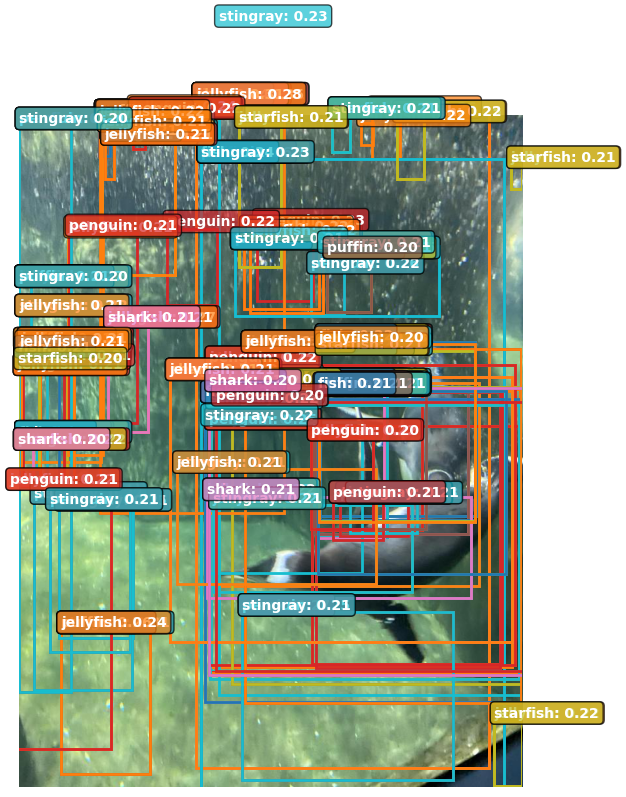

======================================== Adapter ========================================


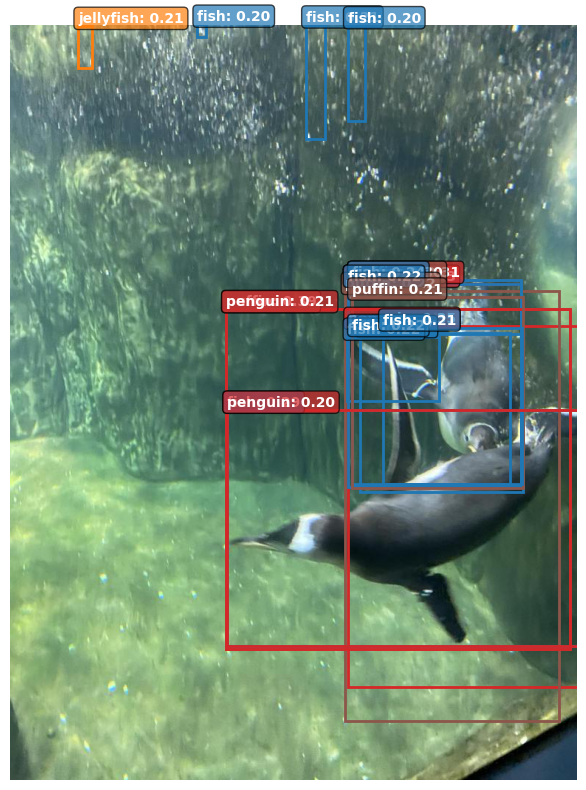

In [23]:
print("="*40+ " Linear Probe " + "="*40)
visualize_predictions('./Aquarium-Combined/test/IMG_2347_jpeg_jpg.rf.7c71ac4b9301eb358cd4a832844dedcb.jpg',
                      linear_probe_model,
                      processor,
                      device)
print("="*40+ " Adapter " + "="*40)
visualize_predictions('./Aquarium-Combined/test/IMG_2347_jpeg_jpg.rf.7c71ac4b9301eb358cd4a832844dedcb.jpg',
                      adapter_model,
                      processor,
                      device)

======================================== Linear Probe ========================================


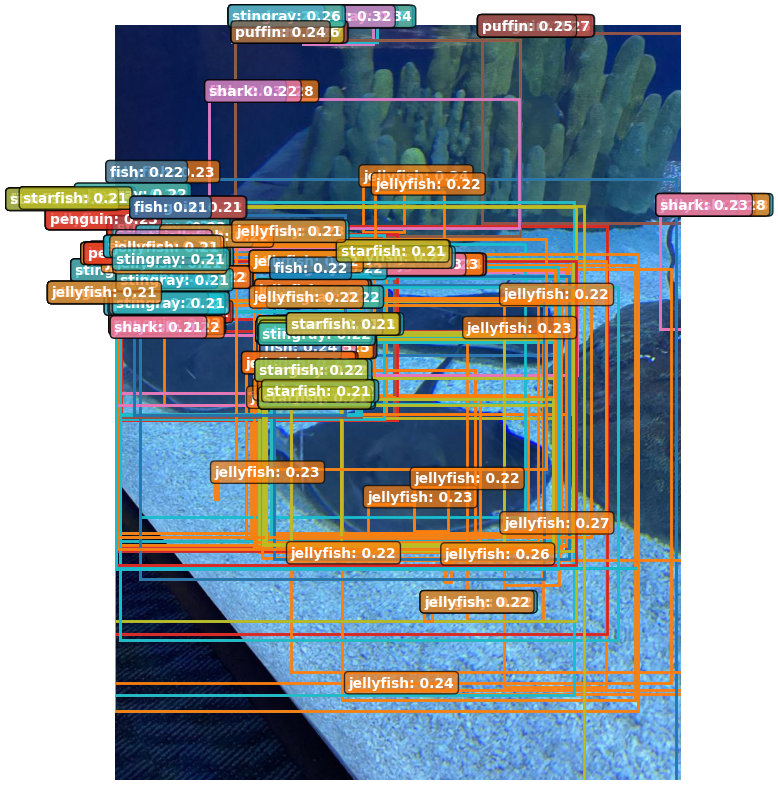

======================================== Adapter ========================================


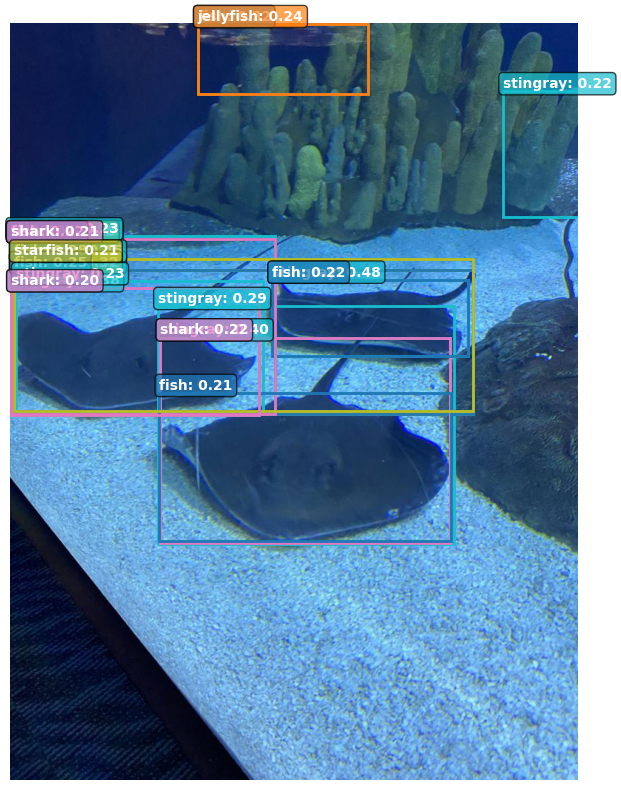

In [24]:
print("="*40+ " Linear Probe " + "="*40)
visualize_predictions('./Aquarium-Combined/test/IMG_2588_jpeg_jpg.rf.cb9cea8f05891cfd55a3e93f2908201f.jpg',
                      linear_probe_model,
                      processor,
                      device)
print("="*40+ " Adapter " + "="*40)
visualize_predictions('./Aquarium-Combined/test/IMG_2588_jpeg_jpg.rf.cb9cea8f05891cfd55a3e93f2908201f.jpg',
                      adapter_model,
                      processor,
                      device)

### Question 1

As we can clearly see the mAP of linear probe is practically 0. This and the bounding boxes generated by this method show that the features learned by the model on normal data is not enough for this kind of domain shift. When we use the linear probe method we assume that the features extracted by the intermidate layers are good and sufficient enough, we only change the last classification layer. In this case the domain shift includes changes to the color (blue and green tint in the water) and lighting conditions. In these new conditions simply Re-Weighting the features is not enough.


### Question 2

In Linear probe 1.89% of all the model parameters are updated while in Adapter 2.34% of the parameters are updated. The fact that Linear probe does not change the features and is essentially a Re-Weighting of the features makes it perform poorly in extreme domain shift situations like the one we have here. The fact that we are using only a limited number of examples for each class (few shot learning) makes Full-FT extremely prone to overfitting. The models capacity in Full-Ft is too much compared to the limited data we have (we have 47M params and 70 training data!), Adapter on the other hand, has far less parameters making it ideal for few shot learning while introducing non-linearity allowing it perform better in domain shift compared to Linear Probe.


### Question 3

I have provided the results of the models on 2 images from the test set. The treshold has been set on 0.2, As you can see for almost all the predictions the confidence score is less then 0.5. However it is evident that the Adapter has an overall higher confidence compared to Linear probe. In both cases the Adapter has correctly identified the location of the objects, although there are some noisy predictions, but the result is a lot cleaner than the Linear Prob one. In Linear Probe there are many predictions with low confidence and it seems they are placed almost randomly showing the model as failed in understanding the pattern in this dataset. 

Adapter, with the help on non-linearity and changing the intermidate features greatly outperforms Linear Probe in the given task, but there is clear room for improvment in this method. Increasing the shots of learning or adding adapters to other parts of the model can greatly improve the results acheived by this method.